### Binning (Discretization) 
#### continuous numbers ko groups (bins) me convert karna

#### “Badi continuous values ko chhote groups me tod dena”

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv('../3/train.csv', usecols=['Age', 'Fare', 'Survived'])

In [5]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [6]:
df.dropna(inplace=True) # Dropping the rows with missing values

In [7]:
df.shape

(714, 3)

In [13]:
# First column ko skip karke baaki sab columns ko feature set mein store karna
X = df.iloc[:, 1:]

# Dataset ki last column ko prediction target ke liye store karna
y = df.iloc[:, 0]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
X_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [16]:
clf = DecisionTreeClassifier()

In [17]:
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [18]:
y_pred = clf.predict(X_test)

In [19]:
accuracy_score(y_test, y_pred)

0.6363636363636364

In [23]:
np.mean(cross_val_score(DecisionTreeClassifier(), X, y, cv=10, scoring='accuracy'))
# cv = Cross Validation (data ko multiple parts/folds me divide karke model ko baar-baar test karna)
# cv=10 ka matlab: data ko 10 parts (folds) me split kiya jata hai
# har fold par model train + test hota hai aur accuracy milti hai
# scoring='accuracy' ka matlab: performance measure accuracy hai
# cross_val_score() → har fold ki accuracy return karta hai (list form me)
# np.mean() → un 10 accuracies ka average (final model performance) nikalta hai

np.float64(0.63589593114241)

In [ ]:
# KBinsDiscretizer ek ML preprocessing tool hai jo continuous numbers (real values) ko groups (bins) me convert karta hai.

kbin_age = KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='quantile')
# KBinsDiscretizer → continuous data (Age) ko bins/categories me convert karta hai
# n_bins=15 → data ko 15 equal groups (bins) me divide karega
# encode='ordinal' → bins ko numbers (0,1,2,...14) ke form me encode karega
# strategy='quantile' → har bin me approx equal number of data points rakhega

kbin_fare = KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='quantile')
# Fare column ke liye bhi same process:
# continuous Fare values ko 15 quantile-based bins me convert karta hai
# aur unhe ordinal numbers (0 to 14) me encode karta hai

# Quantile ka simple meaning:
# 👉 data ko equal parts (sections) me divide karna

In [ ]:
trf = ColumnTransformer([
    ('first', kbin_age,[0]),
    ('second', kbin_fare,[1])
])
# ColumnTransformer → different columns par different preprocessing apply karta hai
# 'first' → Age column (index 0) par kbin_age (binning) apply ho raha hai
# 'second' → Fare column (index 1) par kbin_fare apply ho raha hai

In [30]:
X_train_trf = trf.fit_transform(X_train)
# fit → training data se patterns/bins learn karta hai
# transform → learned rules ke according X_train ko convert karta hai


X_test_trf = trf.transform(X_test)
# test data ko same learned transformation apply karta hai
# (important: test data par fit nahi karte)

c:\Users\harsh\Desktop\Saloni\ml\.venv\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\harsh\Desktop\Saloni\ml\.venv\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [31]:
trf.named_transformers_['first'].bin_edges_
# 'first' transformer (Age) ke bin boundaries show karta hai
# matlab Age values kis-kis range me divide hui hain (cut points)

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [40]:
output = pd.DataFrame({
    'age': X_train['Age'],
    'age_trf': X_train_trf[:, 0],
    'fare': X_train['Fare'],
    'fare_trf': X_train_trf[:, 1]
})
# DataFrame banaya ja raha hai comparison ke liye
# 'age' → original Age values (before transformation)
# 'age_trf' → transformed Age values (KBinsDiscretizer ke baad bins/labels)
# X_train_trf[:, 0] → transformed output ka first column (Age)
# 'fare' → original Fare values
# 'fare_trf' → transformed Fare values (bins me convert hone ke baad)
# X_train_trf[:, 1] → transformed output ka second column (Fare)

In [41]:
output['age_labels'] = pd.cut(
    x=X_train['Age'],
    bins=trf.named_transformers_['first'].bin_edges_[0].tolist()
)
# pd.cut → continuous Age values ko predefined bins me convert karta hai
# x=X_train['Age'] → original Age column
# bins=... → KBinsDiscretizer se nikle hue Age ke bin boundaries use ho rahe hain
# bin_edges_[0] → Age transformer ke cut points (boundaries)
# .tolist() → numpy array ko list me convert karta hai


output['fare_labels'] = pd.cut(
    x=X_train['Fare'],
    bins=trf.named_transformers_['second'].bin_edges_[0].tolist()
)
# pd.cut → Fare values ko bhi same bins me convert karta hai
# x=X_train['Fare'] → original Fare column
# bins=... → Fare ke learned bin edges use ho rahe hain
# bin_edges_[0] → Fare column ke cut points
# .tolist() → list format me convert for pd.cut

In [ ]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
606,30.0,8.0,7.8958,3.0,"(28.0, 30.0]","(7.775, 7.896]"
769,32.0,9.0,8.3625,4.0,"(30.0, 32.0]","(8.158, 10.5]"
299,50.0,13.0,247.5208,14.0,"(47.0, 54.0]","(108.9, 512.329]"
646,19.0,3.0,7.8958,3.0,"(16.0, 19.0]","(7.775, 7.896]"
554,22.0,4.0,7.7750,2.0,"(21.0, 23.0]","(7.25, 7.775]"


In [35]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [ ]:
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [37]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

c:\Users\harsh\Desktop\Saloni\ml\.venv\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\harsh\Desktop\Saloni\ml\.venv\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


np.float64(0.6316705790297339)

In [42]:
def discretize(bins, strategy):
    # function banaya gaya hai jisme bins aur strategy input lete hain

    kbin_age = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    # Age column ke liye binning transformer
    # n_bins → kitne groups banane hain
    # encode='ordinal' → output 0,1,2,... form me milega
    # strategy → bins kaise banenge (quantile/uniform/kmeans)

    kbin_fare = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    # Fare column ke liye same binning process


    trf = ColumnTransformer([
        ('first', kbin_age, [0]),
        ('second', kbin_fare, [1])
    ])
    # ColumnTransformer → Age aur Fare par alag-alag transformations apply karta hai
    # 'first' → Age column (index 0)
    # 'second' → Fare column (index 1)


    X_trf = trf.fit_transform(X)
    # fit → training data se bins learn karta hai
    # transform → X ko binned values me convert karta hai


    print(np.mean(cross_val_score(DecisionTreeClassifier(), X, y, cv=10, scoring='accuracy')))
    # model (Decision Tree) ko 10-fold cross validation se evaluate karta hai
    # har fold ki accuracy ka average print karta hai


    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")
    # original Age distribution plot (before binning)


    plt.subplot(122)
    plt.hist(X_trf[:,0], color='red')
    plt.title("After")
    # transformed Age distribution (after binning)


    plt.show()


    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")
    # original Fare distribution plot


    plt.subplot(122)
    plt.hist(X_trf[:,1], color='red')
    plt.title("Fare")
    # transformed Fare distribution (binned values)


    plt.show()

0.6345070422535211


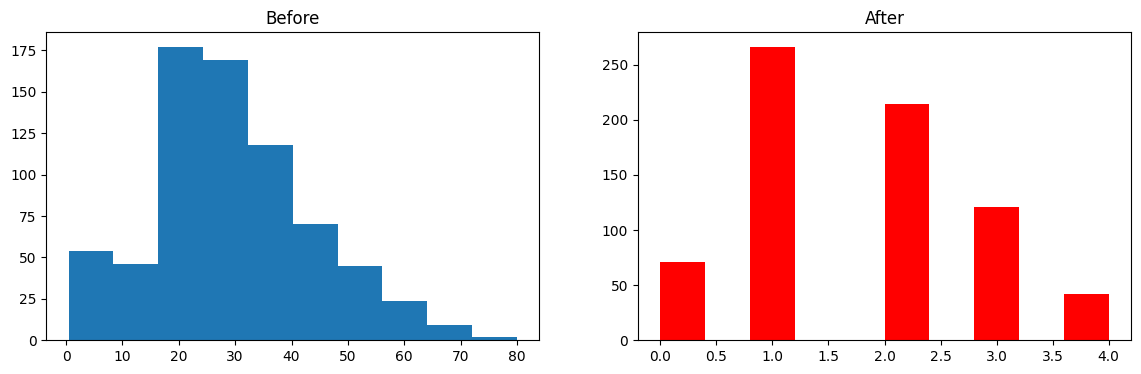

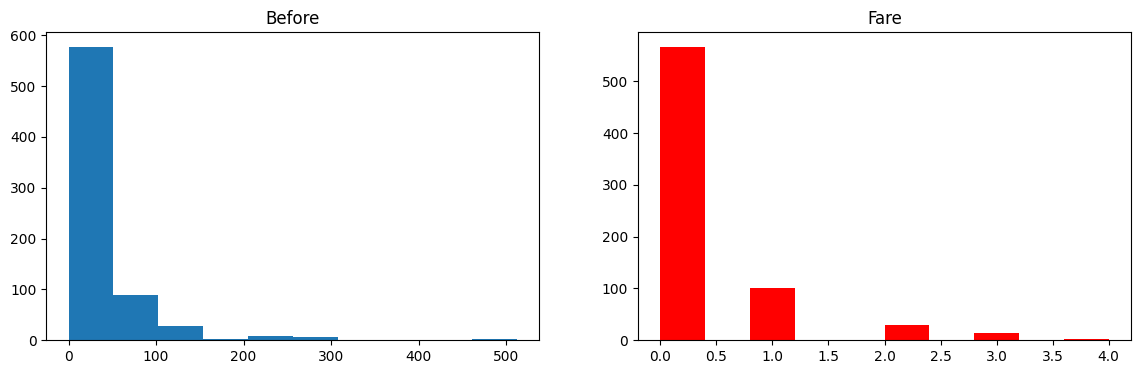

In [43]:
discretize(5, 'kmeans')
# function ko call kiya ja raha hai
# bins = 5 → Age aur Fare ko 5 groups me divide karega
# strategy = 'kmeans' → bins clustering (KMeans algorithm) ke basis par banenge
# matlab similar values ko ek group me cluster karke bin create hoga

# inside function:
# 1. Age + Fare ko 5 clusters me convert kiya jayega
# 2. Decision Tree model ki average accuracy print hogi (10-fold CV se)
# 3. Before vs After histograms show honge (distribution comparison)